## Paper

In [1]:
from matplotlib import pyplot as plt
import numpy as np

from predhpc import paper
from predhpc.util import plot_util

%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
paper.initialize_paper_parameters(gen_dir="..", notebook=True)
ALL_FIGURES = dict()

### Fig. 1: Background

Figure saved to /home/cgillon/homedir/predhpc/results/paper/1B.png  & .svg


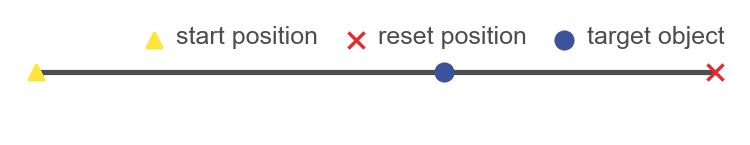

In [32]:
fig, panel = 1, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/1D.png  & .svg


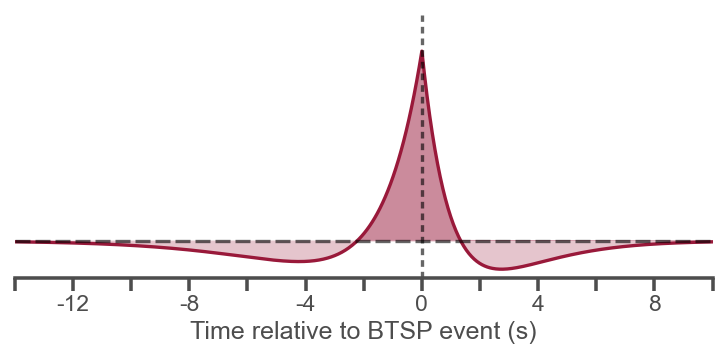

In [35]:
fig, panel = 1, "D"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(fig=fig, panel=panel)

### Fig. 2: Linear track
With this seed, BTSP event is recorded at step 513 and applied at step 1207.

In [6]:
linear_learner = paper.run_linear(max_time_min=2.0)

 15%|█████▉                                 | 608/4000 [00:00<00:04, 750.00it/s]

BTSP event recorded at step 513 (15.39 sec).


 32%|████████████▏                         | 1289/4000 [00:01<00:03, 728.84it/s]

BTSP update applied at step 1207 (36.21 sec).


100%|██████████████████████████████████████| 4000/4000 [00:05<00:00, 708.87it/s]


Finishing last trajectory.


1278it [00:01, 692.59it/s]

Only reached target 4 times (target: 10).
Trajectory lengths (5) to date: 31.67 +/- 17.74 sec each
Trajectory lengths (5) to date: 1055.80 +/- 591.42 steps each
1 BTSP event triggered (allowed from steps 0 to 5278): occurred at step 513.
No weight normalization applied (max value of 0.7783 <= 1).


Figure saved to /home/cgillon/homedir/predhpc/results/paper/2A.png  & .svg


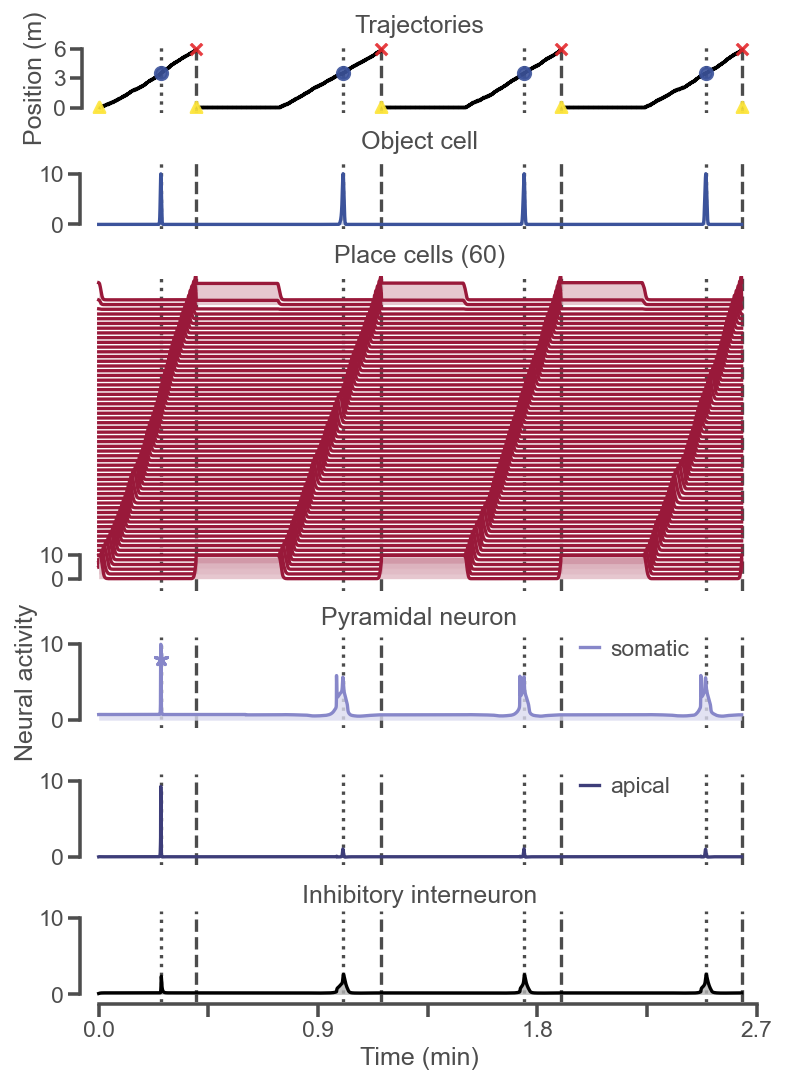

In [11]:
fig, panel = 2, "A"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/2B.png  & .svg


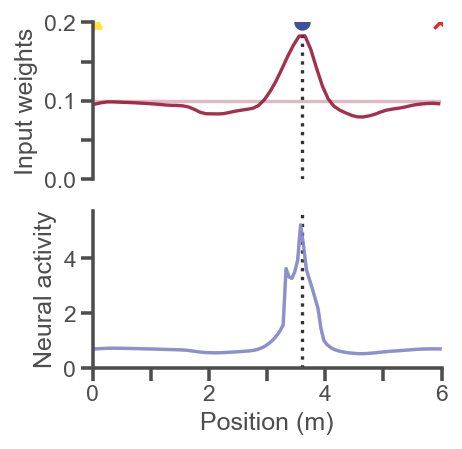

In [12]:
fig, panel = 2, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/2C.png  & .svg


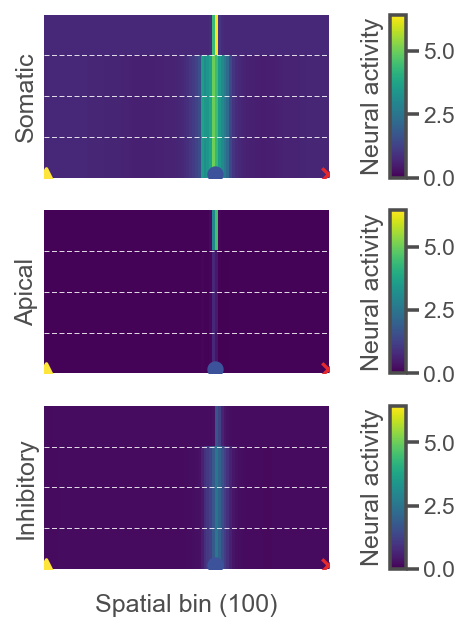

In [13]:
fig, panel = 2, "C"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(linear_learner, fig=fig, panel=panel)

### Fig. 3: Speed and PF width
Very fast with multiple cores (30 sec-1 min). Much longer sequentially.  

In [14]:
speed_data = paper.run_linear_fct("linear_speeds", overwrite=False, num_jobs=30)

Loading data from ../results/paper/speed_data_18.npz.
No weight normalization applied (max value of 0.9467 <= 1).


Figure saved to /home/cgillon/homedir/predhpc/results/paper/3A.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/3A.png  & .svg


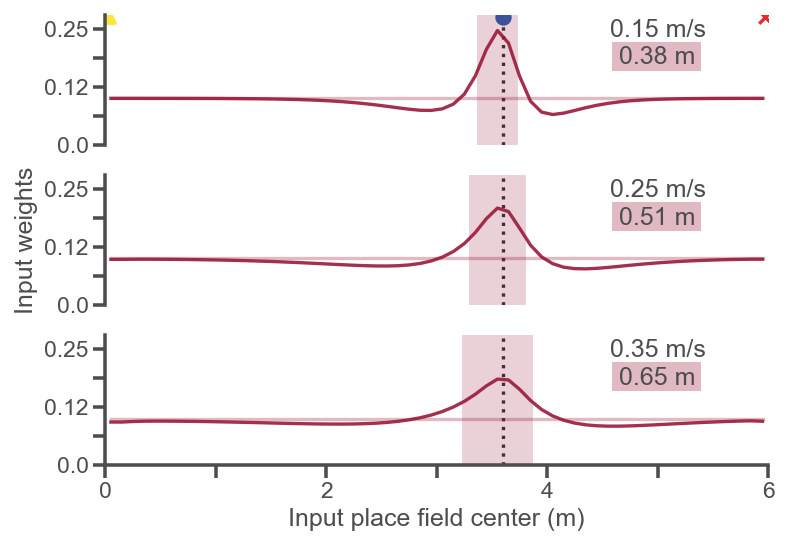

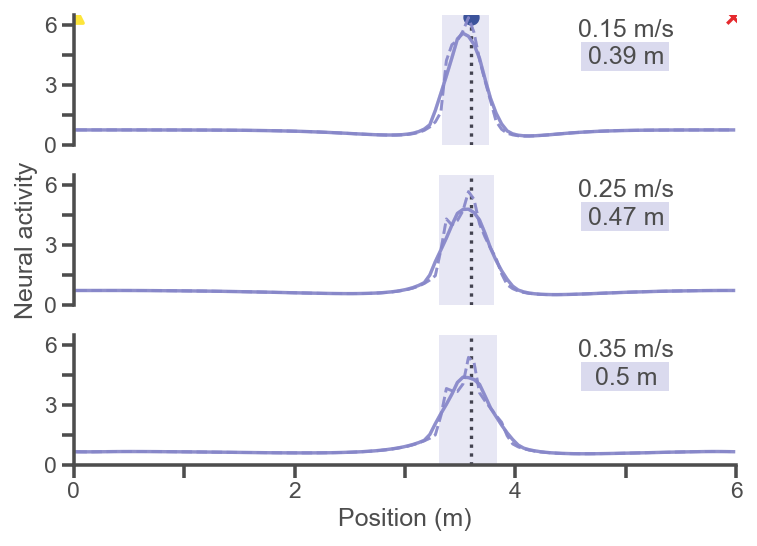

In [15]:
fig, panel = 3, "A"
for PF_type in ["weights", "history"]:
    ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(speed_data, fig=fig, panel=panel, PF_type=PF_type)

With this seed, the regression equations obtained are:  
- Input place cell weights: y = 1.31x + 0.18
- Neural activity history: y = 0.54x + 0.31

Figure saved to /home/cgillon/homedir/predhpc/results/paper/3B.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/3B.png  & .svg


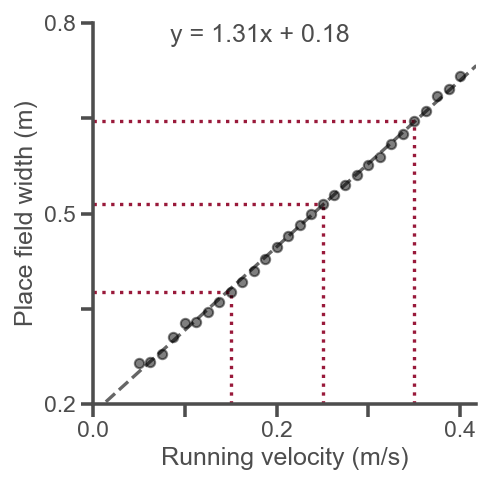

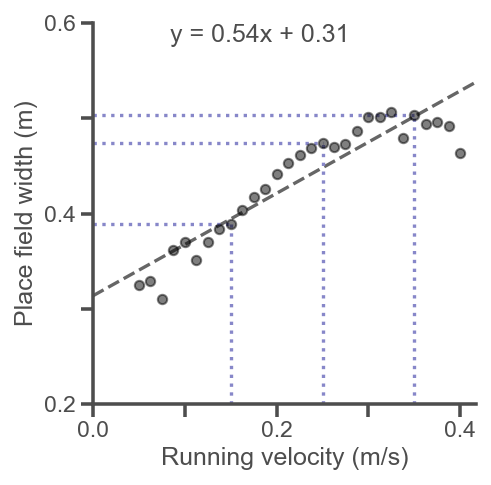

In [16]:
fig, panel = 3, "B"
for PF_type in ["weights", "history"]:
    ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(speed_data, fig=fig, panel=panel, PF_type=PF_type)

### Fig. 4: Effect of linear shifts
Fast with multiple cores (3-6 min). Much longer sequentially.  

In [17]:
shift_data = paper.run_linear_fct("linear_shifts", overwrite=False, num_jobs=30)

Loading data from ../results/paper/shift_data_18.npz.
No weight normalization applied (max value of 0.9580 <= 1).


Figure saved to /home/cgillon/homedir/predhpc/results/paper/4A.png  & .svg


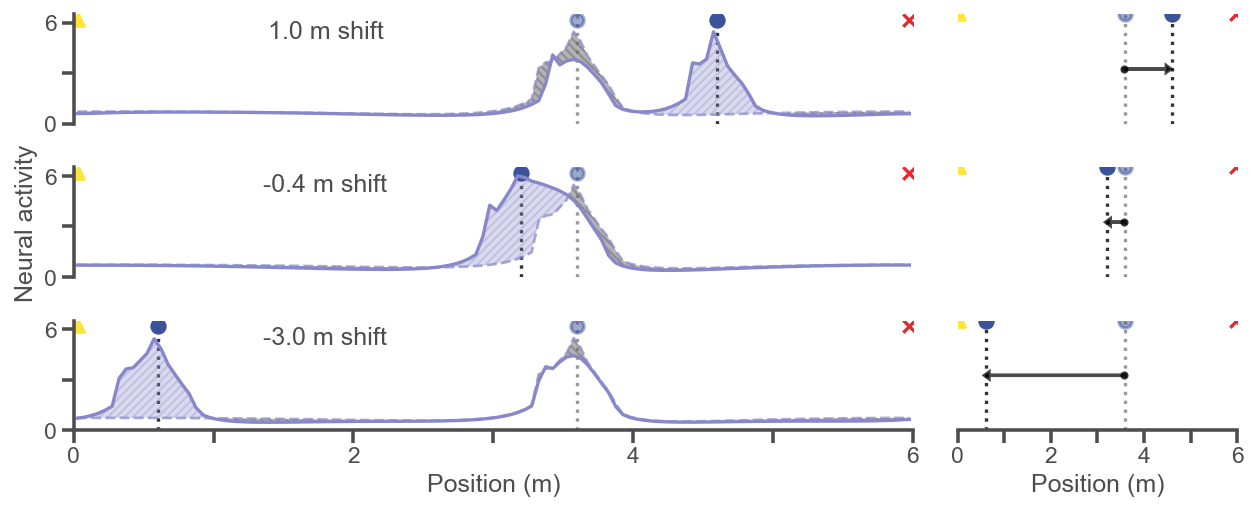

In [18]:
fig, panel = 4, "A"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(shift_data, fig=fig, panel=panel, PF_type="history")

Figure saved to /home/cgillon/homedir/predhpc/results/paper/4B.png  & .svg


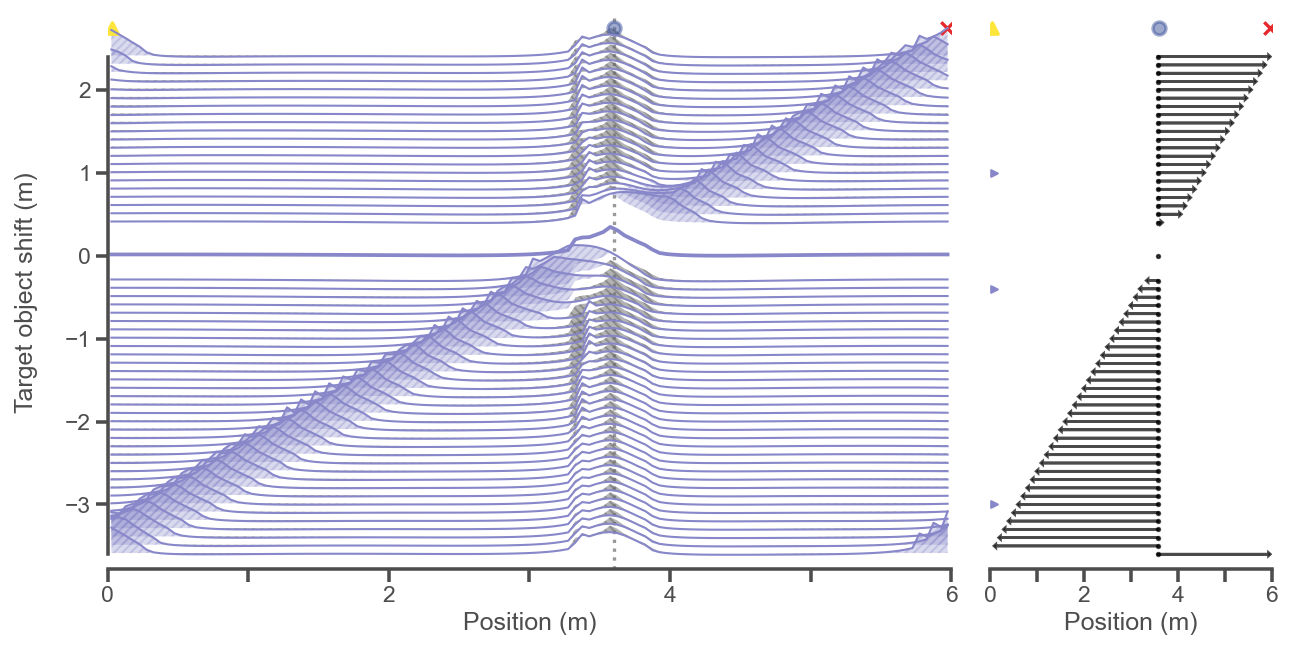

In [19]:
fig, panel = 4, "B"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(shift_data, fig=fig, panel=panel, PF_type="history")

### Fig. 5: 2D environment and teleportation
With this seed, the BTSP event is recorded at step 1097 and applied at step 1791.

In [4]:
learner = paper.run_openfield_corridor()

  6%|██▏                                  | 1159/20000 [00:03<00:51, 363.97it/s]

BTSP event recorded at step 1097 (32.91 sec).


  9%|███▍                                 | 1876/20000 [00:05<00:40, 452.36it/s]

BTSP update applied at step 1791 (53.73 sec).


100%|████████████████████████████████████| 20000/20000 [00:52<00:00, 382.57it/s]

Reached target 9 times.
Trajectory lengths (10): 60.00 +/- 0.00 sec each
Trajectory lengths (10): 2000.00 +/- 0.00 steps each
1 BTSP event triggered (allowed from steps 0 to 19999): occurred at step 1097.
No weight normalization applied (max value of 0.9180 <= 1).


Reward reached 9/15 times in 103.00 to 1765.00 steps.


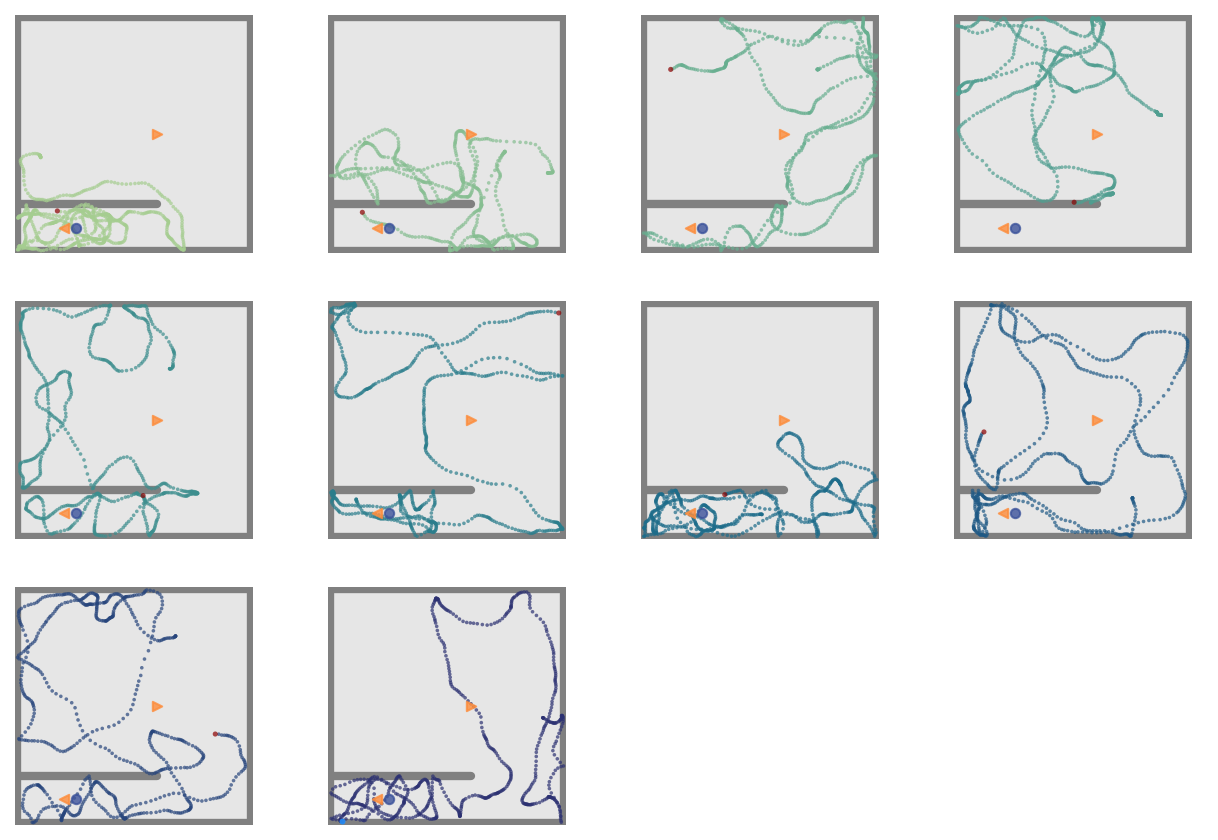

In [10]:
learner.Agent.log_target_reach_times(target_name="reward", log_as_time=False)
learner.Agent.plot_trajectories(separate_axes=True, no_legend=True, s_2D=3);

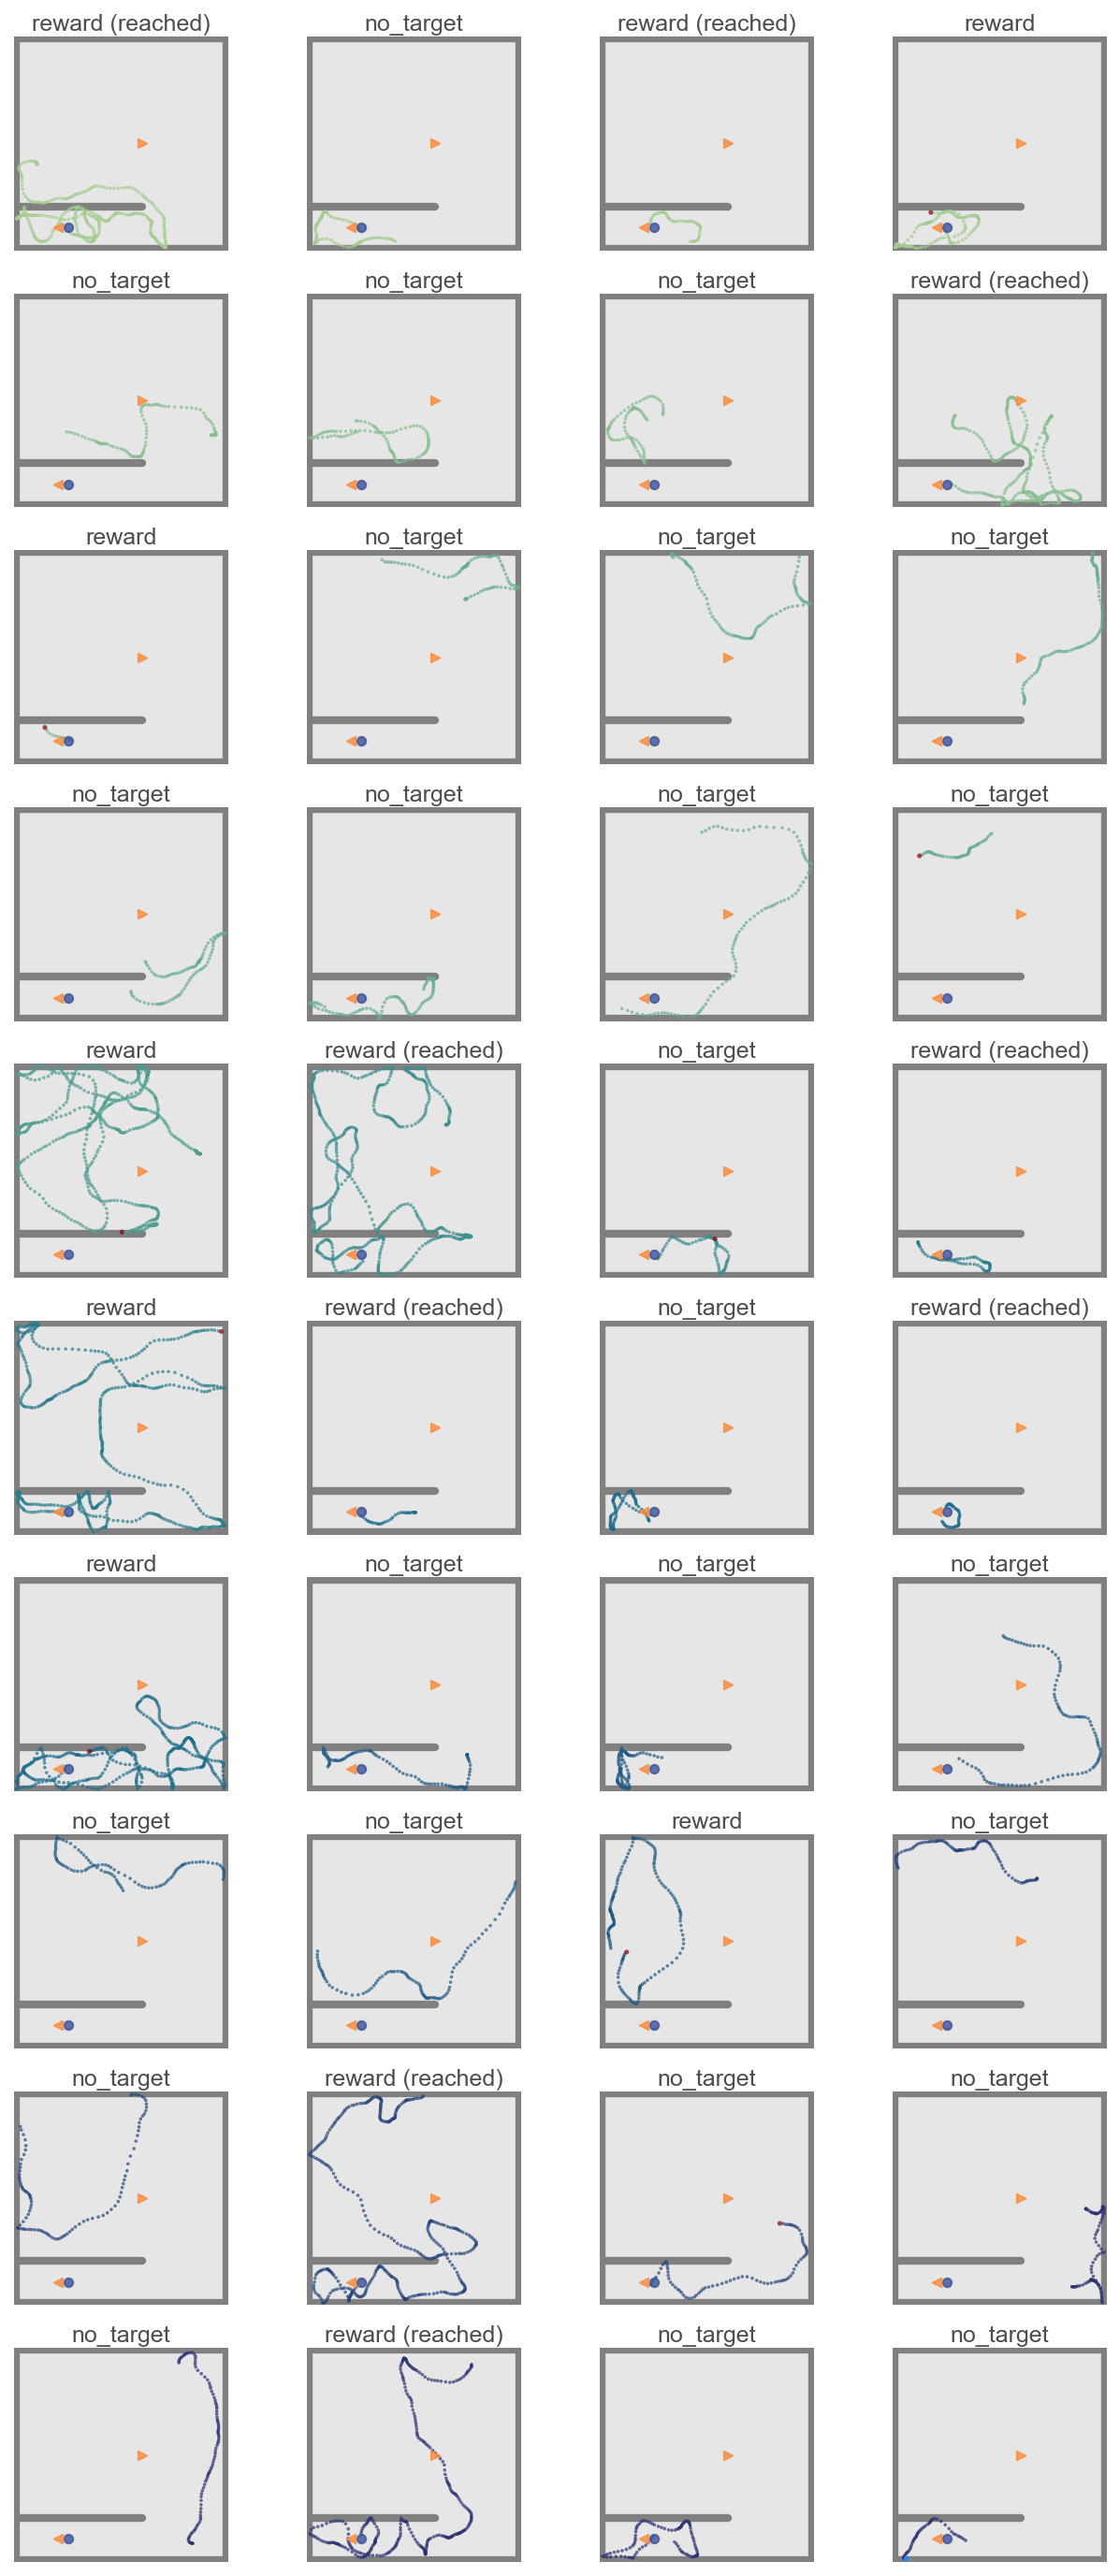

In [9]:
targets = learner.Agent.target_df["object_type_name"]
reached = learner.Agent.target_df["reached_time"]
axes = learner.Agent.plot_trajectories(separate_axes=True, by_target=True, no_legend=True, s_2D=3)
for i, target in enumerate(targets):
    title_str = target
    if not np.isnan(reached[i]):
        title_str = f"{title_str} (reached)"
    axes.ravel()[i].set_title(title_str)

In [7]:
learner.Agent.get_target_probability_df()

,object_df_idx,object_type_num,object_type_name,idx_within_type,position_x,position_y,teleport_pair_num,teleport_direction,target_factor,target_probability
0,0.0,0.0,reward,0.0,0.5,0.2,NaN,NaN,1,0.333333
1,NaN,NaN,no_target,NaN,NaN,NaN,NaN,NaN,2,0.666667


In [8]:
learner.Agent.trajectory_df

,start_position_x,start_position_y,start_step,start_time,end_position_x,end_position_y,end_step,end_time,num_steps_total,time_total
0,0.360918,1.702047,0,0.0,0.611143,0.327791,1500.0,45.0,1500.0,45.0
1,0.912657,1.693365,1500,45.0,0.988088,0.528514,3000.0,90.0,1500.0,45.0
2,1.332727,1.572411,3000,90.0,1.796702,1.398985,4500.0,135.0,1500.0,45.0
3,1.606849,1.378426,4500,135.0,0.409656,0.365617,6000.0,180.0,1500.0,45.0
4,1.007048,1.785338,6000,180.0,1.205004,0.033076,7500.0,225.0,1500.0,45.0
5,1.945244,0.939677,7500,225.0,0.349562,0.012755,9000.0,270.0,1500.0,45.0
6,0.559781,1.863354,9000,270.0,0.988677,0.392111,10500.0,315.0,1500.0,45.0
7,0.201791,0.286314,10500,315.0,0.765330,0.308654,12000.0,360.0,1500.0,45.0
8,1.880346,0.765900,12000,360.0,1.272370,0.273740,13500.0,405.0,1500.0,45.0
9,1.343322,1.897785,13500,405.0,1.222763,0.138829,15000.0,450.0,1500.0,45.0


In [10]:
learner.Agent.target_df

,object_idx,object_type_name,object_type_num,position_x,position_y,set_step,set_time,random_walk_periods,reached_step,reached_time,num_random_walk_steps,random_walk_time,num_steps_total,time_total
0,0.0,reward,0.0,0.5,0.2,0,0.00,"[[0, 300]]",1088.0,32.64,300.0,9.00,1088.0,32.64
1,NaN,no_target,NaN,NaN,NaN,1088,32.64,"[[1088, 1388]]",NaN,NaN,300.0,9.00,300.0,9.00
2,0.0,reward,0.0,0.5,0.2,1388,41.64,[],NaN,NaN,0.0,0.00,112.0,3.36
3,0.0,reward,0.0,0.5,0.2,1500,45.00,"[[1500, 1800], [1800, 2100], [2100, 2400], [24...",NaN,NaN,1500.0,45.00,1500.0,45.00
4,NaN,no_target,NaN,NaN,NaN,3000,90.00,"[[3000, 3300]]",NaN,NaN,300.0,9.00,300.0,9.00
5,0.0,reward,0.0,0.5,0.2,3300,99.00,"[[3300, 3600], [3600, 3900], [3900, 4200], [42...",NaN,NaN,1200.0,36.00,1200.0,36.00
6,NaN,no_target,NaN,NaN,NaN,4500,135.00,"[[4500, 4800]]",NaN,NaN,300.0,9.00,300.0,9.00
7,0.0,reward,0.0,0.5,0.2,4800,144.00,"[[4800, 5100], [5100, 5400], [5400, 5700], [57...",5974.0,179.22,1174.0,35.22,1174.0,35.22
8,NaN,no_target,NaN,NaN,NaN,5974,179.22,"[[5974, 6000]]",NaN,NaN,26.0,0.78,26.0,0.78
9,NaN,no_target,NaN,NaN,NaN,6000,180.00,"[[6000, 6300]]",NaN,NaN,300.0,9.00,300.0,9.00


Figure saved to /home/cgillon/homedir/predhpc/results/paper/5A-D.png  & .svg


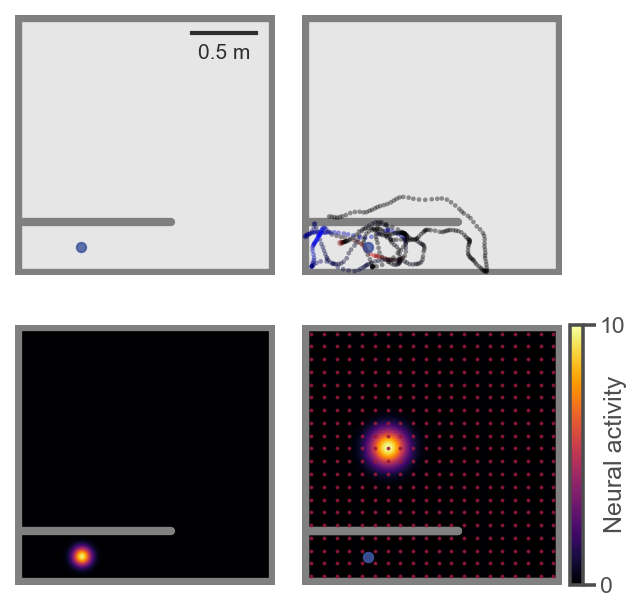

In [85]:
fig, panel = 5, "A-D"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/5E.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/5E.png  & .svg


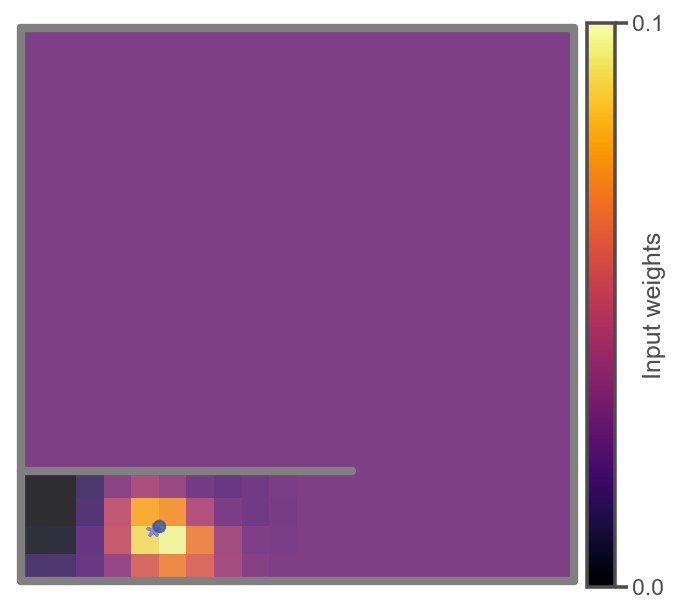

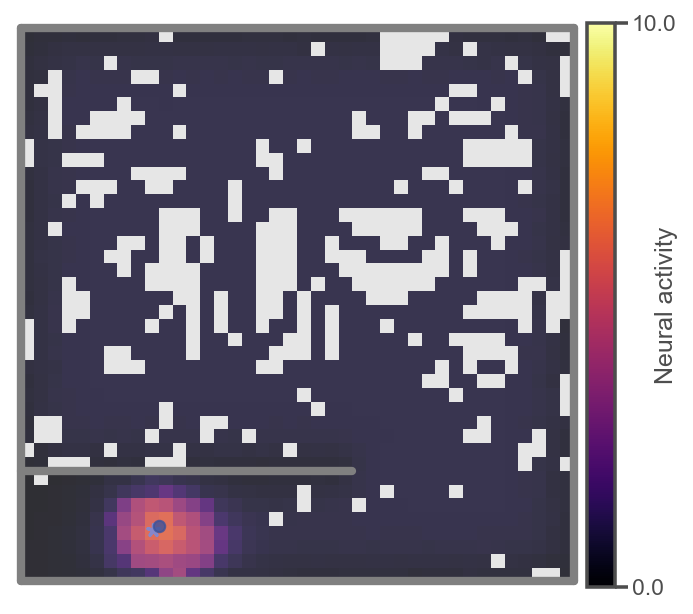

In [58]:
fig, panel = 5, "E"
for PF_type in ["weights", "history"]:
    ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel, PF_type=PF_type)

Figure saved to /home/cgillon/homedir/predhpc/results/paper/5F.png  & .svg


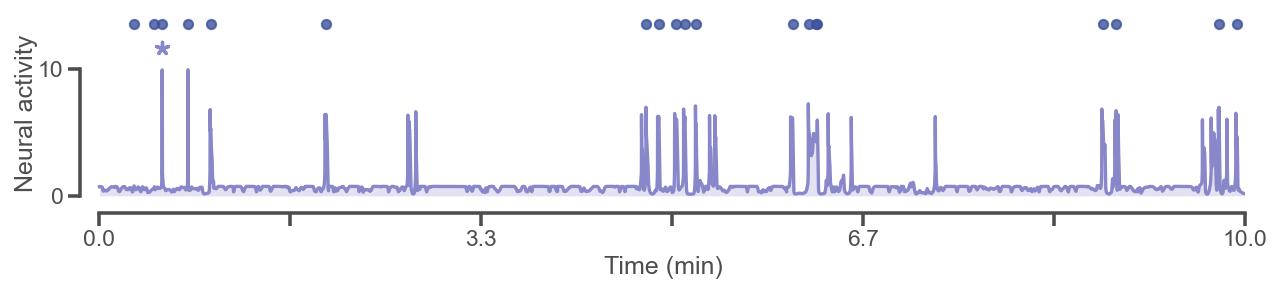

In [30]:
fig, panel = 5, "F"
ALL_FIGURES[f"{fig}{panel}"] = paper.plot_figure_panel(learner.Pyrs, fig=fig, panel=panel)

## Supplemental

Show place fields from multiple simulations.  
Show relationship between number of visits and number of BTSP events.

In [ ]:
learner.Pyrs.SomaticCompartment.plot_BTSP_ramp()
learner.Pyrs.SomaticCompartment.log_max_normalization_value("PCs")

### Fig. 6: Teleportation

In [4]:
from predhpc import run_manager

In [ ]:
initial_end_time = learner.Agent.t
learner.Agent.allow_teleportation(True)
learner.Agent.set_reward_factor(0)
learner.Agent.set_no_target_factor(0)

In [94]:
learner_with_teleport = learner.Pyrs

reward_updater = run_manager.VNUpdater(learner.Agent, target="reward")
teleport_updater = run_manager.VNUpdater(learner.Agent, target="teleport_0_in")

num_BTSP = len(learner.Pyrs.SomaticCompartment.history["BTSP_events"])
while len(learner.Agent.teleportation_df) == 0 or len(learner.Pyrs.SomaticCompartment.history["BTSP_events"]) <= num_BTSP:
    num_teleport = len(learner.Agent.teleportation_df)
    if len(learner.Agent.teleportation_df) == num_teleport:
        updater = teleport_updater
    else:
        learner.Agent.set_reward_factor(3)
        updater = reward_updater
    
    learner_with_teleport = run_manager.learn_openfield_BTSP(
        Pyrs_or_learner=learner_with_teleport,
        use_Hebbian=False,
        max_num_steps=6000,
        updater=updater,
    )

teleport_idx = len(learner_with_teleport.Agent.teleportation_df) - 1

 34%|██████████████████████████████████▊                                                                    | 2030/6000 [00:05<00:12, 313.29it/s]

Teleported through pair 0 at step 16975 (509.28 sec.)
BTSP event recorded at step 16980 (509.40 sec).


 45%|██████████████████████████████████████████████▌                                                        | 2716/6000 [00:08<00:10, 311.07it/s]

BTSP update applied at step 17674 (530.22 sec).


 60%|█████████████████████████████████████████████████████████████▌                                         | 3589/6000 [00:10<00:07, 323.34it/s]

...

BTSP update applied at step 19229 (576.87 sec).


 76%|█████████████████████████████████████████████████████████████████████████████▊                         | 4531/6000 [00:24<00:13, 109.94it/s]

Teleported through pair 0 at step 19492 (584.79 sec.)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 6000/6000 [00:29<00:00, 203.82it/s]

Reached target 4 times.
Trajectory lengths (11) to date: 57.27 +/- 8.62 sec each
Trajectory lengths (11) to date: 1909.09 +/- 287.48 steps each
2 BTSP events triggered (allowed from steps 15000 to 20999): occurred between steps 16980 and 18535, inclusively.
Max. weight normalization value applied: 1.2520.


A: Teleportation ports  
B: Teleportation trajectory  
C: Remapped place field

### Fig. 7: Multiple targets

A: environment with multiple objects  
B: object fields  
C: trajectory examples  
D: 5 examples PFs  
E: all place fields overlaid  
F: BTSP events  
G: relationship between visits and number of BTSP events  

### Fig. 8: Remapping

A: remapping  
B: remapped  
C: correlation pre post

### Save figures

In [20]:
SAVE = True

In [21]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        fig = ax.ravel()[0].figure if isinstance(ax, np.ndarray) else ax.figure
        plot_util.save_figure(fig, key, no_timestamp=True)

Saving 12 figures...
Figure saved to /home/cgillon/homedir/predhpc/results/paper/1B.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/1D.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/2A.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/2B.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/2C.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/3A.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/3B.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/4A.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/4B.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/5A-D.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/5E.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/results/paper/5F.png  & .svg
